In [1]:
# Cell 1 — always run this first
import os
os.chdir('/home/darius/qgis_projects/land_change_detector')
print("Working directory:", os.getcwd())

Working directory: /home/darius/qgis_projects/land_change_detector


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '/home/darius/qgis_projects/land_change_detector')

# ← ADD load_band_crop here
from utils.raster_utils import load_raster, load_band_crop, get_raster_info

# ── BEFORE: June 2019 ─────────────────────────────────────────────
R10m_BEFORE = (
    "data/before/"
    "S2B_MSIL2A_20190601T102029_N0500_R065_T31SGV_20230724T191309.SAFE/"
    "GRANULE/L2A_T31SGV_A011674_20190601T102031/IMG_DATA/R10m"
)

# ── AFTER: August 2025 ────────────────────────────────────────────
R10m_AFTER = (
    "data/after/"
    "S2B_MSIL2A_20250828T101559_N0511_R065_T31SGV_20250828T130342.SAFE/"
    "GRANULE/L2A_T31SGV_A044278_20250828T102319/IMG_DATA/R10m"
)

# ── Same crop for both ────────────────────────────────────────────
CROP = dict(x_off=4000, y_off=4000, x_size=2000, y_size=2000)

# ── Load BEFORE bands ─────────────────────────────────────────────
red_b,   gt, proj = load_band_crop(f"{R10m_BEFORE}/T31SGV_20190601T102029_B04_10m.jp2", **CROP)
green_b, _,  _    = load_band_crop(f"{R10m_BEFORE}/T31SGV_20190601T102029_B03_10m.jp2", **CROP)
blue_b,  _,  _    = load_band_crop(f"{R10m_BEFORE}/T31SGV_20190601T102029_B02_10m.jp2", **CROP)
nir_b,   _,  _    = load_band_crop(f"{R10m_BEFORE}/T31SGV_20190601T102029_B08_10m.jp2", **CROP)

# ── Load AFTER bands ──────────────────────────────────────────────
red_a,   _,  _    = load_band_crop(f"{R10m_AFTER}/T31SGV_20250828T101559_B04_10m.jp2", **CROP)
green_a, _,  _    = load_band_crop(f"{R10m_AFTER}/T31SGV_20250828T101559_B03_10m.jp2", **CROP)
blue_a,  _,  _    = load_band_crop(f"{R10m_AFTER}/T31SGV_20250828T101559_B02_10m.jp2", **CROP)
nir_a,   _,  _    = load_band_crop(f"{R10m_AFTER}/T31SGV_20250828T101559_B08_10m.jp2", **CROP)

print(f"✅ Before shape : {red_b.shape}")
print(f"✅ After shape  : {red_a.shape}")
print(f"✅ RAM used     : ~{(red_b.nbytes * 8) / 1e6:.0f} MB (8 bands total)")

✅ Before shape : (2000, 2000)
✅ After shape  : (2000, 2000)
✅ RAM used     : ~128 MB (8 bands total)


In [3]:
from utils.raster_utils import load_cloud_mask

SCL_BEFORE = (
    "data/before/"
    "S2B_MSIL2A_20190601T102029_N0500_R065_T31SGV_20230724T191309.SAFE/"
    "GRANULE/L2A_T31SGV_A011674_20190601T102031/IMG_DATA/R20m/"
    "T31SGV_20190601T102029_SCL_20m.jp2"
)

SCL_AFTER = (
    "data/after/"
    "S2B_MSIL2A_20250828T101559_N0511_R065_T31SGV_20250828T130342.SAFE/"
    "GRANULE/L2A_T31SGV_A044278_20250828T102319/IMG_DATA/R20m/"
    "T31SGV_20250828T101559_SCL_20m.jp2"
)

cloud_b, valid_b = load_cloud_mask(SCL_BEFORE,
                                    x_off=2000, y_off=2000,
                                    x_size=1000, y_size=1000,
                                    target_size=red_b.shape)

cloud_a, valid_a = load_cloud_mask(SCL_AFTER,
                                    x_off=2000, y_off=2000,
                                    x_size=1000, y_size=1000,
                                    target_size=red_a.shape)

valid_both = valid_b & valid_a
print(f"\nPixels valid in both dates: {valid_both.sum():,}")
print(f"Pixels masked out         : {(~valid_both).sum():,}")

Cloud coverage in crop: 17.0%
Valid pixels          : 3,319,100 / 4,000,000
Cloud coverage in crop: 0.0%
Valid pixels          : 4,000,000 / 4,000,000

Pixels valid in both dates: 3,319,100
Pixels masked out         : 680,900


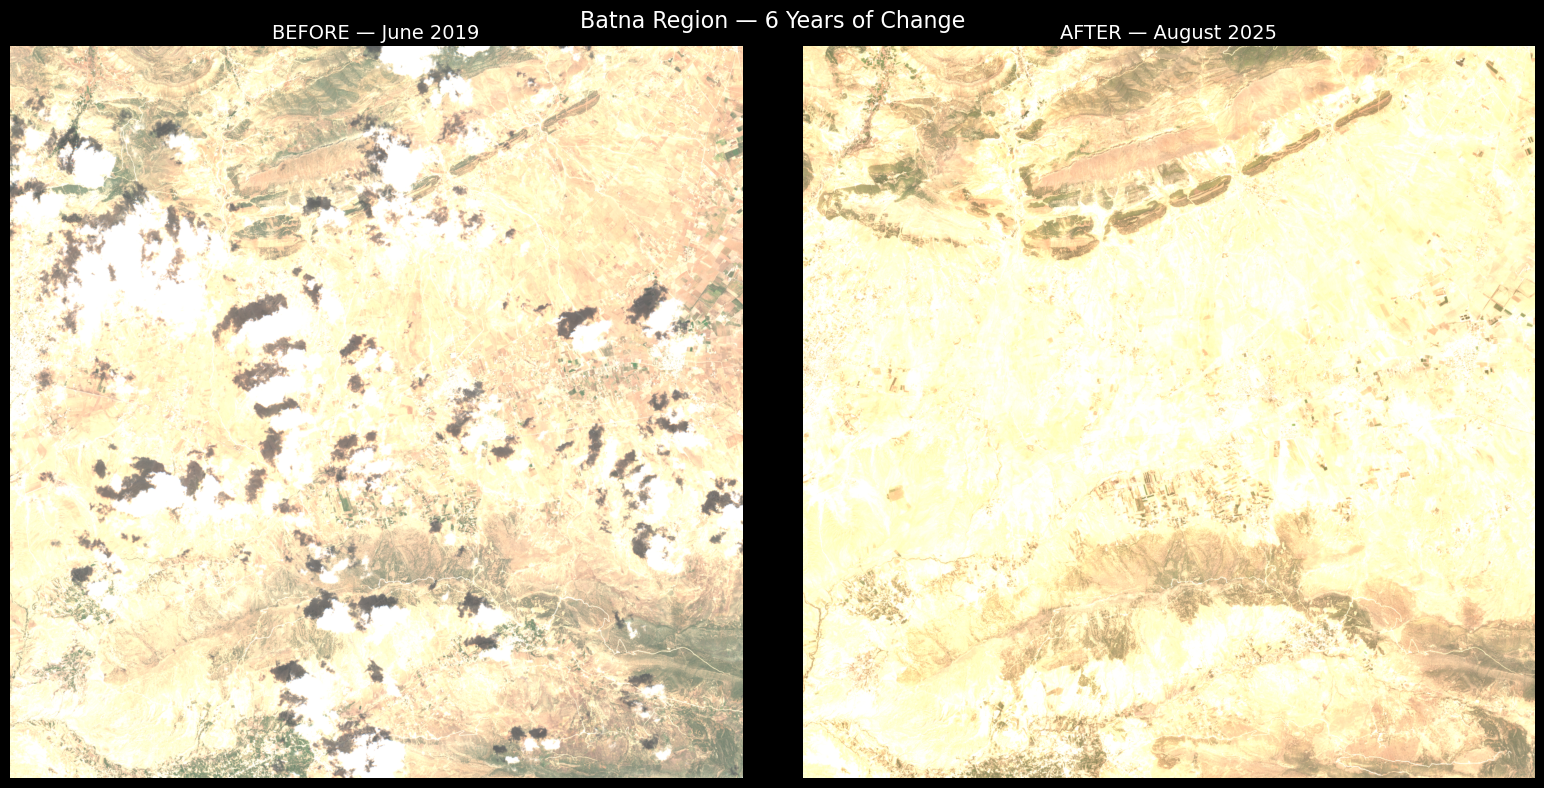

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Before
rgb_b = np.stack([red_b, green_b, blue_b], axis=-1)
axes[0].imshow(np.clip(rgb_b / 3000.0, 0, 1))
axes[0].set_title("BEFORE — June 2019", fontsize=14)
axes[0].axis('off')

# After
rgb_a = np.stack([red_a, green_a, blue_a], axis=-1)
axes[1].imshow(np.clip(rgb_a / 3000.0, 0, 1))
axes[1].set_title("AFTER — August 2025", fontsize=14)
axes[1].axis('off')

plt.suptitle("Batna Region — 6 Years of Change", fontsize=16)
plt.tight_layout()
plt.savefig("data/before_after_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

Auto threshold (Otsu): 675.98
Valid pixels   : 3,319,100
Changed pixels : 1,175,098
Change %       : 35.40% (of valid pixels)


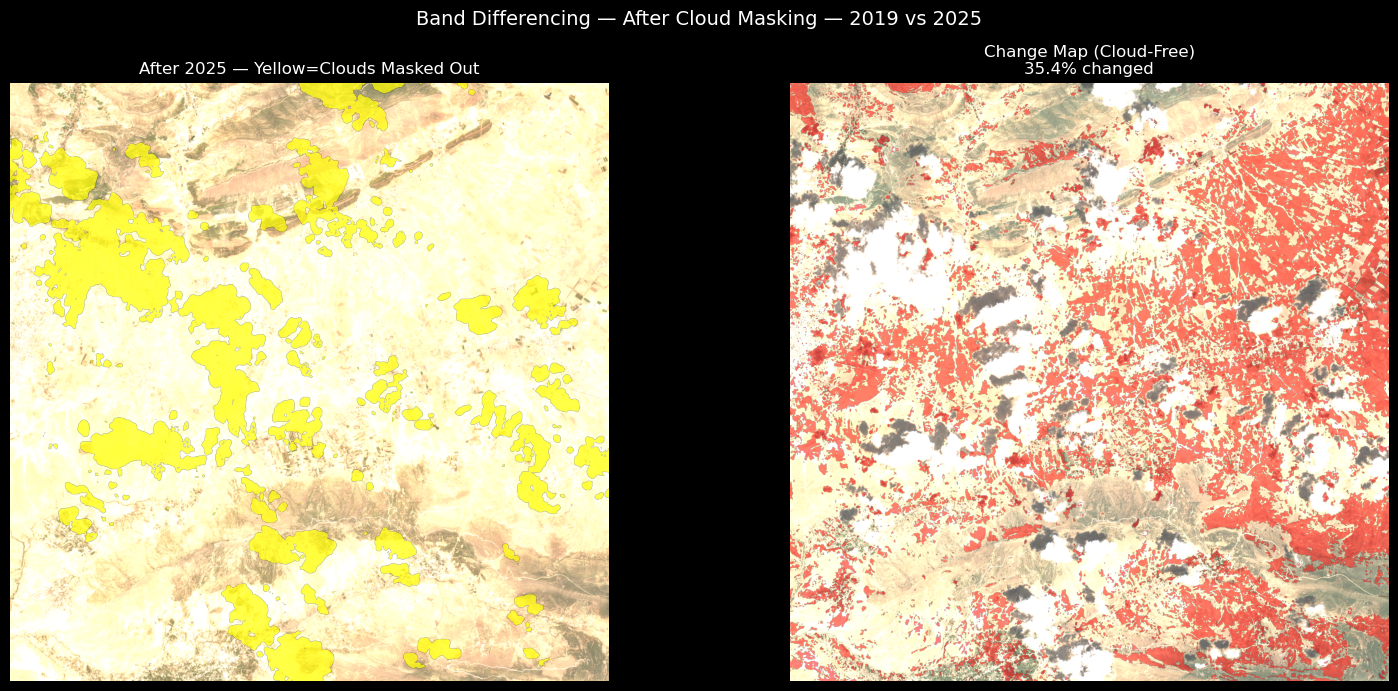

In [5]:
from algorithms.band_differencing import run_band_differencing

# Apply cloud mask before running algorithm
red_b_masked = np.where(valid_both, red_b, np.nan)
red_a_masked = np.where(valid_both, red_a, np.nan)

# Run with REAL cloud-free data
results_clean = run_band_differencing(red_b_masked, red_a_masked)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Yellow overlay = masked clouds
cloud_overlay = np.zeros((*valid_both.shape, 4), dtype=np.float32)
cloud_overlay[~valid_both] = [1, 1, 0, 0.7]

# Red overlay = detected changes
change_overlay = np.zeros((*results_clean['change_mask'].shape, 4), dtype=np.float32)
change_overlay[results_clean['change_mask']] = [1, 0, 0, 0.5]

axes[0].imshow(np.clip(rgb_a / 3000.0, 0, 1))
axes[0].imshow(cloud_overlay)
axes[0].set_title("After 2025 — Yellow=Clouds Masked Out", fontsize=12)
axes[0].axis('off')

axes[1].imshow(np.clip(rgb_b / 3000.0, 0, 1))
axes[1].imshow(change_overlay)
axes[1].set_title(f"Change Map (Cloud-Free)\n"
                  f"{results_clean['change_pct']:.1f}% changed", fontsize=12)
axes[1].axis('off')

plt.suptitle("Band Differencing — After Cloud Masking — 2019 vs 2025", fontsize=14)
plt.tight_layout()
plt.savefig("data/band_diff_cloud_masked.png", dpi=150, bbox_inches='tight')
plt.show()

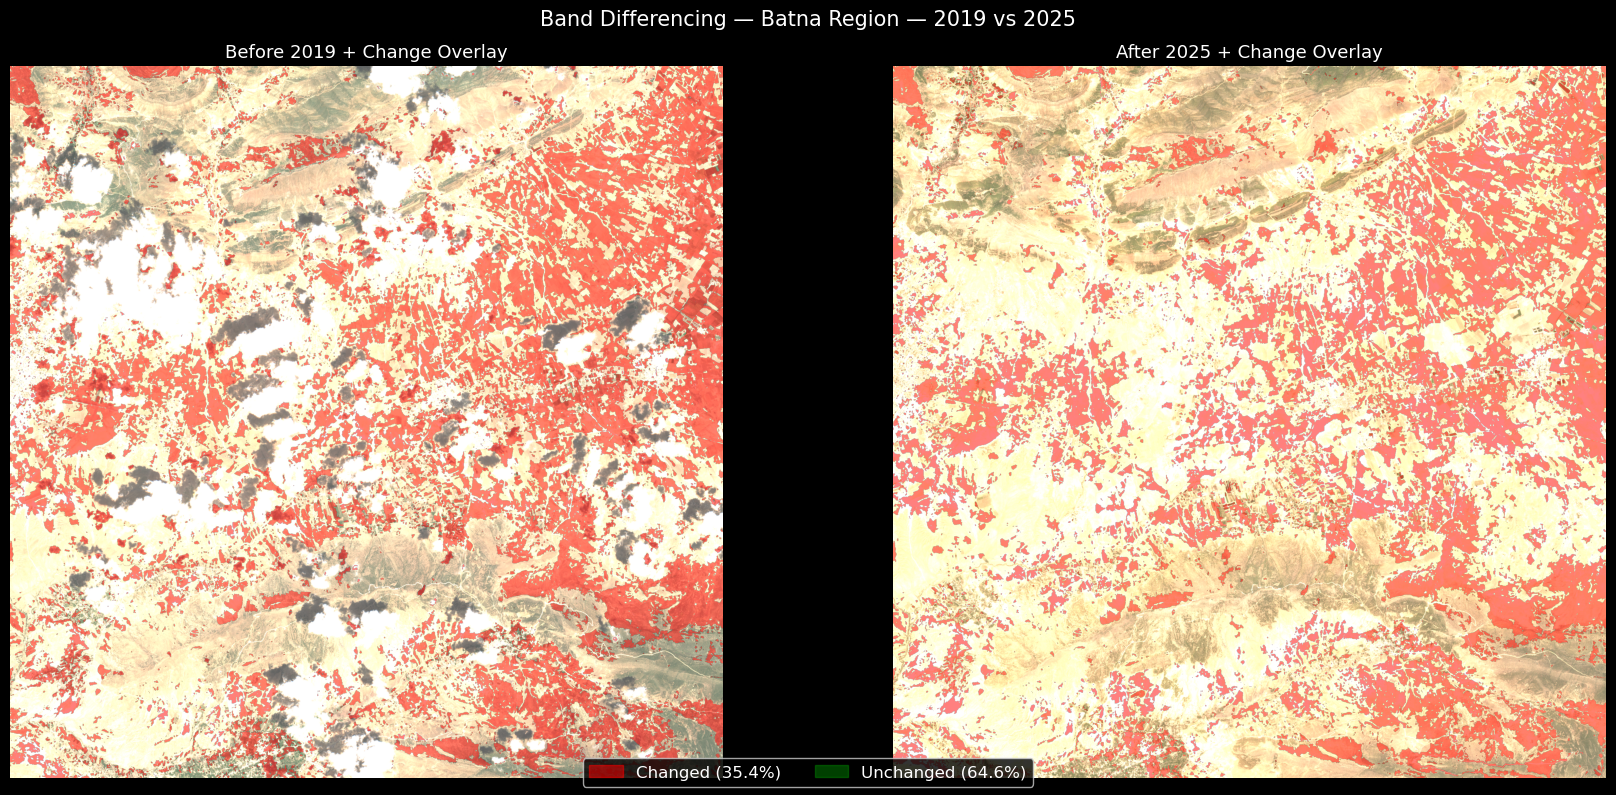

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Reuse cloud-masked outputs from Cell 5
change_mask = results_clean['change_mask']
change_pct = results_clean['change_pct']
unchanged_pct = 100 - change_pct

# -- Left: Before image with change overlay --
rgb_b_display = np.clip(rgb_b / 3000.0, 0, 1)

# Create RGBA overlay (red = changed, transparent = unchanged)
overlay = np.zeros((*change_mask.shape, 4), dtype=np.float32)
overlay[change_mask] = [1, 0, 0, 0.5]  # red, 50% transparent

axes[0].imshow(rgb_b_display)
axes[0].imshow(overlay)
axes[0].set_title("Before 2019 + Change Overlay", fontsize=13)
axes[0].axis('off')

# -- Right: After image with change overlay --
rgb_a_display = np.clip(rgb_a / 3000.0, 0, 1)

axes[1].imshow(rgb_a_display)
axes[1].imshow(overlay)
axes[1].set_title("After 2025 + Change Overlay", fontsize=13)
axes[1].axis('off')

# Legend
changed_patch = mpatches.Patch(color='red', alpha=0.5, label=f'Changed ({change_pct:.1f}%)')
unchanged_patch = mpatches.Patch(color='green', alpha=0.5, label=f'Unchanged ({unchanged_pct:.1f}%)')
fig.legend(handles=[changed_patch, unchanged_patch], loc='lower center', fontsize=12, ncol=2)

plt.suptitle("Band Differencing — Batna Region — 2019 vs 2025", fontsize=15)
plt.tight_layout()
plt.savefig("data/change_overlay.png", dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'results' is not defined

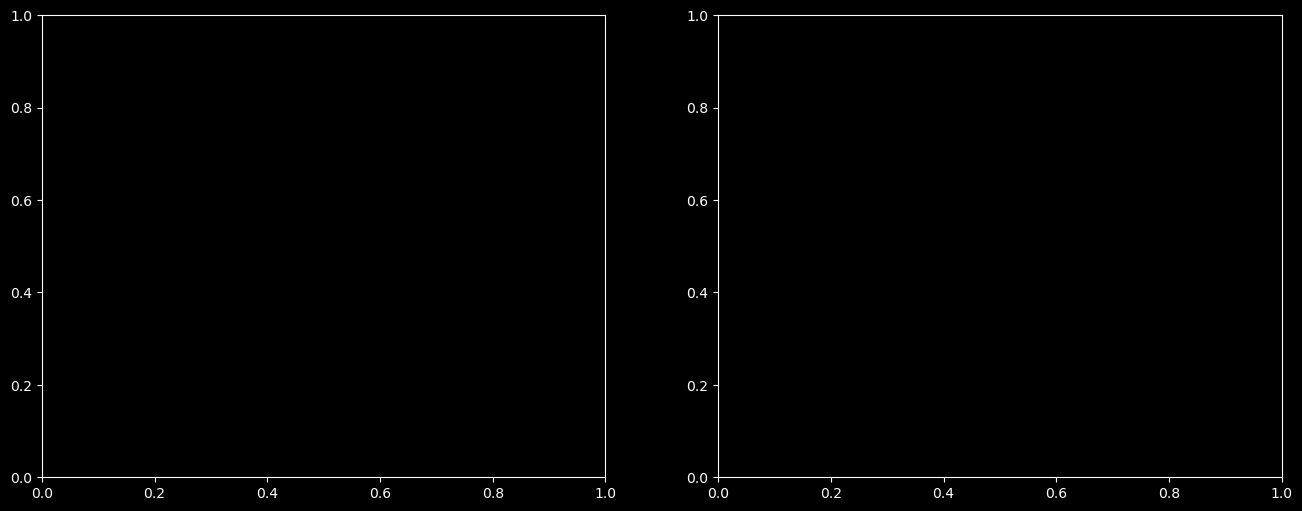

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Signed difference (not absolute)
signed_diff = results['diff']

# Only show pixels that changed
masked_diff = np.where(results['change_mask'], signed_diff, np.nan)

# Plot with diverging colormap
im = axes[0].imshow(masked_diff, cmap='RdBu', 
                     vmin=-3000, vmax=3000)
axes[0].set_title("Change Direction\n(Blue=got darker, Red=got brighter)", 
                   fontsize=12)
axes[0].axis('off')
plt.colorbar(im, ax=axes[0], fraction=0.046)

# Histogram of changes
axes[1].hist(signed_diff[results['change_mask']], 
             bins=100, color='steelblue', edgecolor='none')
axes[1].axvline(0, color='red', linewidth=2, label='No change line')
axes[1].set_xlabel("Pixel Value Change (After - Before)")
axes[1].set_ylabel("Number of pixels")
axes[1].set_title("Distribution of Changes")
axes[1].legend()

plt.tight_layout()
plt.savefig("data/change_direction.png", dpi=150, bbox_inches='tight')
plt.show()

# Print summary
positive = (signed_diff[results['change_mask']] > 0).sum()
negative = (signed_diff[results['change_mask']] < 0).sum()
print(f"Got BRIGHTER (positive diff): {positive:,} pixels")
print(f"Got DARKER   (negative diff): {negative:,} pixels")

In [8]:
print("=== CLOUD MASK DIAGNOSIS ===")
print(f"valid_b  (before cloud-free pixels): {valid_b.sum():,}")
print(f"valid_a  (after  cloud-free pixels): {valid_a.sum():,}")
print(f"valid_both (both cloud-free)        : {valid_both.sum():,}")
print(f"Total pixels                        : {valid_both.size:,}")
print(f"Masked out pixels                   : {(~valid_both).sum():,}")
print(f"Mask % removed                      : {(~valid_both).mean()*100:.1f}%")

print("\n=== MASKED BAND DIAGNOSIS ===")
print(f"NaN in red_b_masked : {np.isnan(red_b_masked).sum():,}")
print(f"NaN in red_a_masked : {np.isnan(red_a_masked).sum():,}")

print("\n=== SCL UNIQUE VALUES ===")
from osgeo import gdal
ds = gdal.Open(SCL_AFTER, gdal.GA_ReadOnly)
scl_sample = ds.GetRasterBand(1).ReadAsArray(2000, 2000, 1000, 1000)
unique, counts = np.unique(scl_sample, return_counts=True)
for v, c in zip(unique, counts):
    labels = {0:'No data', 1:'Saturated', 2:'Dark', 3:'Cloud Shadow',
              4:'Vegetation', 5:'Bare Soil', 6:'Water', 7:'Unclassified',
              8:'Cloud Med', 9:'Cloud High', 10:'Cirrus', 11:'Snow'}
    print(f"  SCL={v:2d} ({labels.get(v,'?'):15s}): {c:,} pixels ({c/scl_sample.size*100:.1f}%)")
ds = None

=== CLOUD MASK DIAGNOSIS ===
valid_b  (before cloud-free pixels): 3,319,100
valid_a  (after  cloud-free pixels): 4,000,000
valid_both (both cloud-free)        : 3,319,100
Total pixels                        : 4,000,000
Masked out pixels                   : 680,900
Mask % removed                      : 17.0%

=== MASKED BAND DIAGNOSIS ===
NaN in red_b_masked : 680,900
NaN in red_a_masked : 680,900

=== SCL UNIQUE VALUES ===
  SCL= 4 (Vegetation     ): 1,085 pixels (0.1%)
  SCL= 5 (Bare Soil      ): 998,915 pixels (99.9%)


Auto threshold (Otsu): 0.1015
Valid pixels      : 3,319,100
Changed pixels    : 448,682
Change %          : 13.52%
  → Vegetation gained : 0.40%
  → Vegetation lost   : 13.97%

NDVI before mean  : 0.165
NDVI after  mean  : 0.101
Delta NDVI  mean  : -0.064


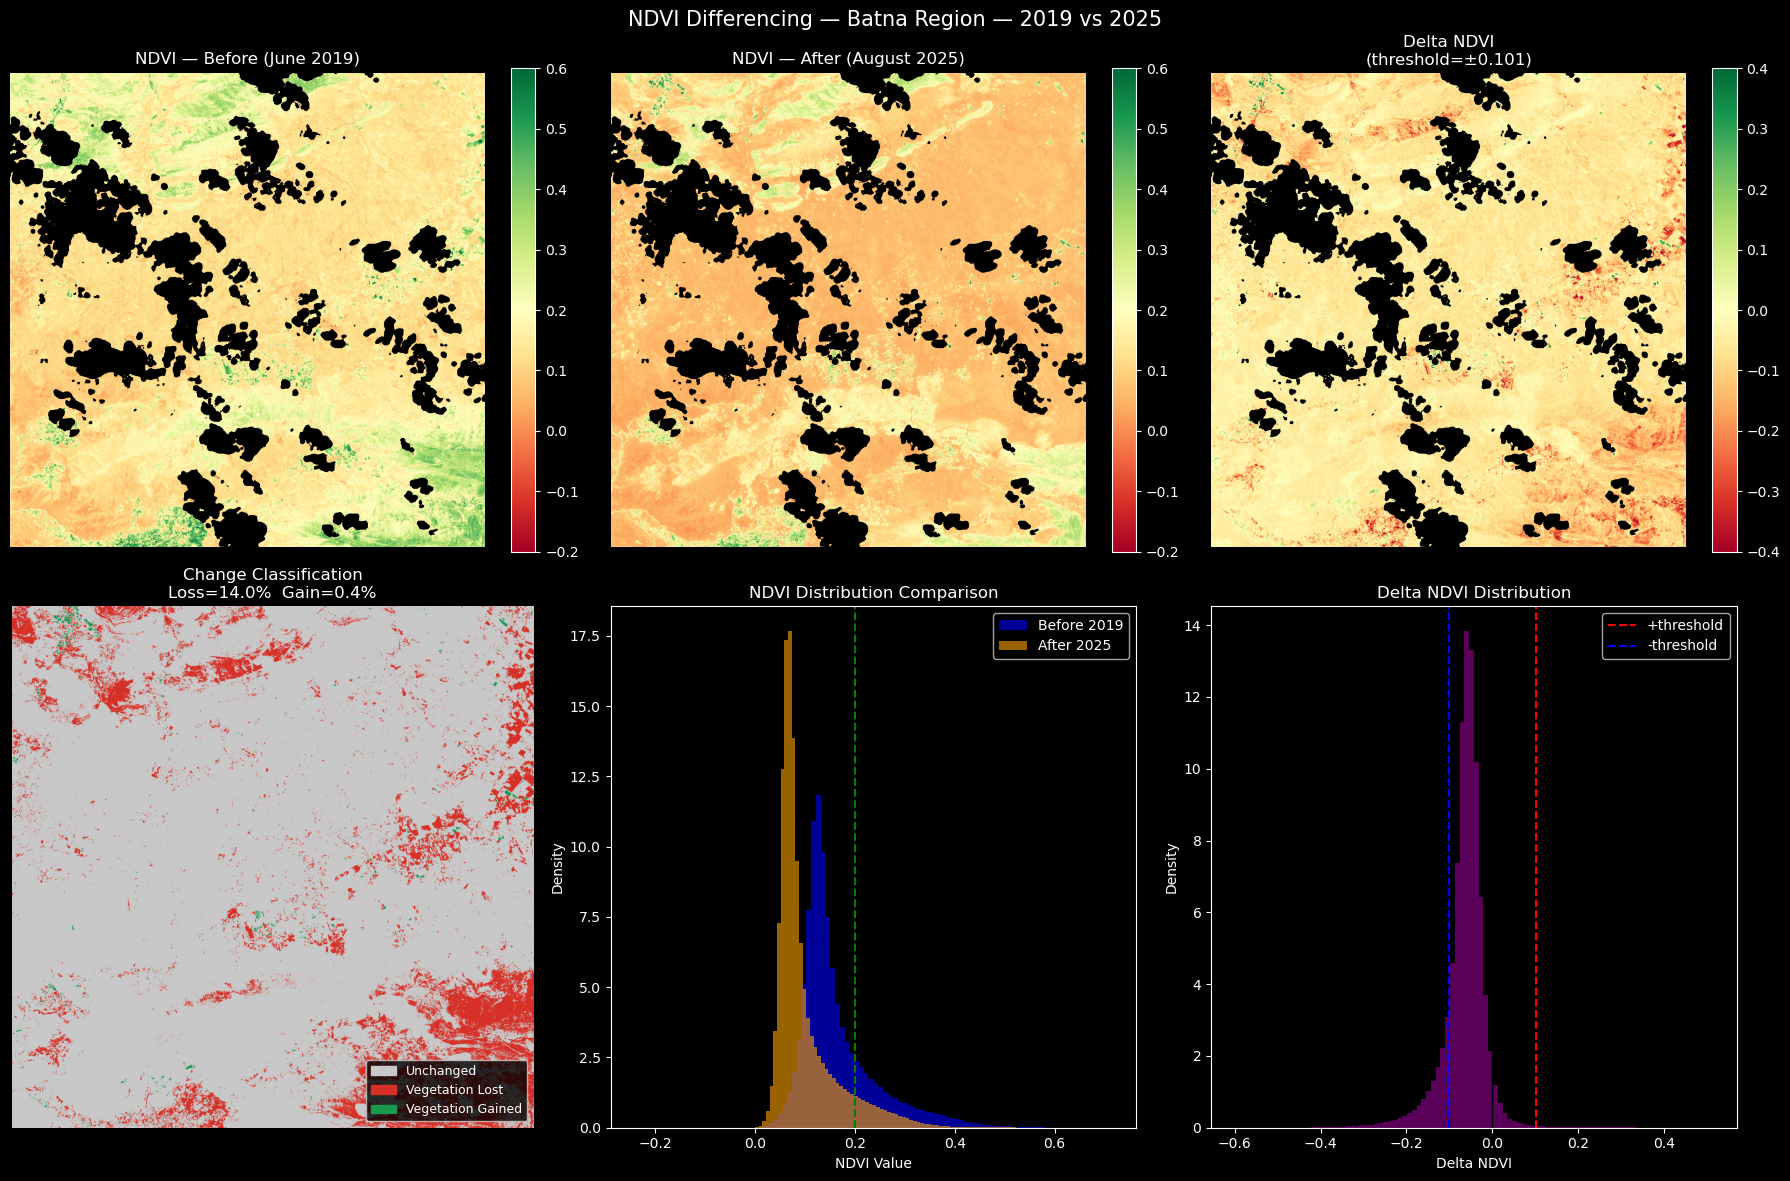

In [9]:
from algorithms.ndvi_differencing import run_ndvi_differencing, compute_ndvi

# Apply cloud mask to NIR bands too
nir_b_masked = np.where(valid_both, nir_b, np.nan)
nir_a_masked = np.where(valid_both, nir_a, np.nan)

# Run NDVI differencing
ndvi_results = run_ndvi_differencing(
    red_b_masked, nir_b_masked,
    red_a_masked, nir_a_masked
)

# ── Visualize ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Row 1: NDVI maps
im0 = axes[0,0].imshow(ndvi_results['ndvi_before'], cmap='RdYlGn', vmin=-0.2, vmax=0.6)
axes[0,0].set_title("NDVI — Before (June 2019)", fontsize=12)
axes[0,0].axis('off')
plt.colorbar(im0, ax=axes[0,0], fraction=0.046)

im1 = axes[0,1].imshow(ndvi_results['ndvi_after'], cmap='RdYlGn', vmin=-0.2, vmax=0.6)
axes[0,1].set_title("NDVI — After (August 2025)", fontsize=12)
axes[0,1].axis('off')
plt.colorbar(im1, ax=axes[0,1], fraction=0.046)

im2 = axes[0,2].imshow(ndvi_results['delta_ndvi'], cmap='RdYlGn', vmin=-0.4, vmax=0.4)
axes[0,2].set_title(f"Delta NDVI\n(threshold=±{ndvi_results['threshold']:.3f})", fontsize=12)
axes[0,2].axis('off')
plt.colorbar(im2, ax=axes[0,2], fraction=0.046)

# Row 2: Change classification
# Build a 3-class map: 0=unchanged, 1=loss, 2=gain
change_class = np.zeros(ndvi_results['change_mask'].shape, dtype=np.uint8)
change_class[ndvi_results['loss_mask']] = 1   # vegetation lost
change_class[ndvi_results['gain_mask']] = 2   # vegetation gained

from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

cmap3 = ListedColormap(['#c8c8c8', '#d73027', '#1a9850'])  # gray, red, green

axes[1,0].imshow(change_class, cmap=cmap3, vmin=0, vmax=2)
axes[1,0].set_title(
    f"Change Classification\n"
    f"Loss={ndvi_results['loss_pct']:.1f}%  "
    f"Gain={ndvi_results['gain_pct']:.1f}%", fontsize=12)
axes[1,0].axis('off')
patches = [
    mpatches.Patch(color='#c8c8c8', label='Unchanged'),
    mpatches.Patch(color='#d73027', label='Vegetation Lost'),
    mpatches.Patch(color='#1a9850', label='Vegetation Gained'),
]
axes[1,0].legend(handles=patches, loc='lower right', fontsize=9)

# NDVI histogram comparison
axes[1,1].hist(ndvi_results['ndvi_before'][~np.isnan(ndvi_results['ndvi_before'])],
               bins=100, alpha=0.6, color='blue', label='Before 2019', density=True)
axes[1,1].hist(ndvi_results['ndvi_after'][~np.isnan(ndvi_results['ndvi_after'])],
               bins=100, alpha=0.6, color='orange', label='After 2025', density=True)
axes[1,1].set_xlabel("NDVI Value")
axes[1,1].set_ylabel("Density")
axes[1,1].set_title("NDVI Distribution Comparison")
axes[1,1].legend()
axes[1,1].axvline(0.2, color='green', linestyle='--', label='Vegetation threshold')

# Delta NDVI histogram
axes[1,2].hist(ndvi_results['delta_ndvi'][~np.isnan(ndvi_results['delta_ndvi'])],
               bins=100, color='purple', alpha=0.7, density=True)
axes[1,2].axvline( ndvi_results['threshold'], color='red',  linestyle='--', label='+threshold')
axes[1,2].axvline(-ndvi_results['threshold'], color='blue', linestyle='--', label='-threshold')
axes[1,2].axvline(0, color='black', linewidth=1)
axes[1,2].set_xlabel("Delta NDVI")
axes[1,2].set_ylabel("Density")
axes[1,2].set_title("Delta NDVI Distribution")
axes[1,2].legend()

plt.suptitle("NDVI Differencing — Batna Region — 2019 vs 2025", fontsize=15)
plt.tight_layout()
plt.savefig("data/ndvi_differencing_results.png", dpi=150, bbox_inches='tight')
plt.show()